# DCGAN desde cero para generar sprites de Pokémon

In [25]:
import os
import requests
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Hiperparámetros

In [26]:
Z_DIM = 100
IMG_SIZE = 64
IMG_CHANNELS = 3
FEATURES_G = 64
FEATURES_D = 64

BATCH_SIZE = 32
NUM_EPOCHS = 50
LR = 2e-4
BETAS = (0.5, 0.999)

DATA_DIR = "pokemon_sprites"
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

## Construcción del dataset

Si ya cuenta con el script proporcionado en la plataforma para construir el dataset,
utilícelo en su lugar (debe dejar las 898 imágenes PNG en `DATA_DIR`). A continuación se
incluye una alternativa autocontenida que descarga los sprites directamente desde el
repositorio público de GitHub de PokeAPI (`PokeAPI/sprites`), por si no cuenta con el
script o desea reproducir el dataset desde cero.

In [27]:
def download_pokemon_sprites(data_dir=DATA_DIR, n_pokemon=898):
    """
    Descarga los sprites frontales estandar desde el repositorio de GitHub de PokeAPI.
    Fuente: https://github.com/PokeAPI/sprites
    """
    os.makedirs(data_dir, exist_ok=True)
    base_url = "https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon"
    downloaded = 0
    for pid in range(1, n_pokemon + 1):
        out_path = os.path.join(data_dir, f"{pid}.png")
        if os.path.exists(out_path):
            downloaded += 1
            continue
        url = f"{base_url}/{pid}.png"
        try:
            resp = requests.get(url, timeout=10)
            if resp.status_code == 200 and len(resp.content) > 0:
                with open(out_path, "wb") as f:
                    f.write(resp.content)
                downloaded += 1
            else:
                print(f"No se pudo descargar #{pid}: HTTP {resp.status_code}")
        except Exception as e:
            print(f"Error descargando #{pid}: {e}")
        if pid % 100 == 0:
            print(f"Progreso: {pid}/{n_pokemon}")
    print(f"Descarga completa: {downloaded}/{n_pokemon} imagenes en '{data_dir}'")

# Descomente la siguiente linea para descargar el dataset (puede tardar varios minutos)
# download_pokemon_sprites()

In [ ]:
class PokemonSpriteDataset(Dataset):
    def __init__(self, data_dir=DATA_DIR, img_size=IMG_SIZE):
        self.paths = sorted([
            os.path.join(data_dir, f) for f in os.listdir(data_dir)
            if f.lower().endswith(".png")
        ])
        assert len(self.paths) > 0, (
            f"No se encontraron imagenes en '{data_dir}'. "
            "Ejecute download_pokemon_sprites()"
        )
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5] * 3, [0.5] * 3),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGBA")
        bg = Image.new("RGBA", img.size, (255, 255, 255, 255))
        composited = Image.alpha_composite(bg, img).convert("RGB")
        return self.transform(composited)


dataset = PokemonSpriteDataset()
dataloader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0
)
print(f"Dataset cargado: {len(dataset)} imagenes, {len(dataloader)} batches por epoca")

Dataset cargado: 898 imagenes, 28 batches por epoca


## Task 1.1 - Generador y Discriminador

In [29]:
class Generator(nn.Module):
    def __init__(self, z_dim=Z_DIM, img_channels=IMG_CHANNELS, features_g=FEATURES_G):
        super().__init__()
        self.net = nn.Sequential(
            # z: (batch, z_dim, 1, 1) -> (batch, features_g*8, 4, 4)
            nn.ConvTranspose2d(z_dim, features_g * 8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),
            # -> (batch, features_g*4, 8, 8)
            nn.ConvTranspose2d(features_g * 8, features_g * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),
            # -> (batch, features_g*2, 16, 16)
            nn.ConvTranspose2d(features_g * 4, features_g * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),
            # -> (batch, features_g, 32, 32)
            nn.ConvTranspose2d(features_g * 2, features_g, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),
            # -> (batch, img_channels, 64, 64)
            nn.ConvTranspose2d(features_g, img_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, img_channels=IMG_CHANNELS, features_d=FEATURES_D):
        super().__init__()
        self.net = nn.Sequential(
            # (batch, 3, 64, 64) -> (batch, features_d, 32, 32)
            nn.Conv2d(img_channels, features_d, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # -> (batch, features_d*2, 16, 16)
            nn.Conv2d(features_d, features_d * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # -> (batch, features_d*4, 8, 8)
            nn.Conv2d(features_d * 2, features_d * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # -> (batch, features_d*8, 4, 4)
            nn.Conv2d(features_d * 4, features_d * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_d * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # -> (batch, 1, 1, 1)
            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        out = self.net(x)
        return out.view(-1)

In [ ]:
def weights_init(m): #Función para inicializar los pesos de la red, recibe como parámetro el módulo actual 
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [31]:
G = Generator().to(device)
D = Discriminator().to(device)
G.apply(weights_init)
D.apply(weights_init)

# Verificacion de formas exactas
z = torch.randn(4, Z_DIM, 1, 1, device=device)
assert G(z).shape == (4, 3, 64, 64), "Forma del generador incorrecta"
assert D(torch.randn(4, 3, 64, 64, device=device)).shape == (4,), "Forma del discriminador incorrecta"
print("Formas verificadas correctamente: G -> (4, 3, 64, 64), D -> (4,)")

Formas verificadas correctamente: G -> (4, 3, 64, 64), D -> (4,)


In [32]:
print(G)

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=

In [33]:
print(D)

Discriminator(
  (net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )


## Task 1.2 - Entrenamiento alternado

In [34]:
criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=LR, betas=BETAS)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=BETAS)

fixed_noise = torch.randn(16, Z_DIM, 1, 1, device=device)

REAL_LABEL = 1.0
FAKE_LABEL = 0.0

losses_G = []
losses_D = []
img_grids_per_epoch = []  # una grilla (tensor) por epoca, generada con fixed_noise

In [ ]:
for epoch in range(NUM_EPOCHS):
    epoch_loss_G = 0.0
    epoch_loss_D = 0.0
    num_batches = 0

    for real_imgs in dataloader:
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # Paso del Discriminador
        D.zero_grad()

        labels_real = torch.full((batch_size,), REAL_LABEL, dtype=torch.float, device=device)
        output_real = D(real_imgs)
        loss_D_real = criterion(output_real, labels_real)

        noise = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
        fake_imgs = G(noise)
        labels_fake = torch.full((batch_size,), FAKE_LABEL, dtype=torch.float, device=device)
        output_fake = D(fake_imgs.detach())  # detach: no propagar gradiente hacia G
        loss_D_fake = criterion(output_fake, labels_fake)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D.step()

        # Paso del Generador
        G.zero_grad()

        noise_g = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
        fake_imgs_for_G = G(noise_g)
        output_for_G = D(fake_imgs_for_G)
        # Truco de Goodfellow: G quiere que D clasifique sus salidas como reales (etiqueta 1)
        loss_G = criterion(output_for_G, labels_real)
        loss_G.backward()
        opt_G.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()
        num_batches += 1

    avg_loss_D = epoch_loss_D / num_batches
    avg_loss_G = epoch_loss_G / num_batches
    losses_D.append(avg_loss_D)
    losses_G.append(avg_loss_G)

    # Grilla de 16 imagenes con ruido fijo, para visualizar la evolucion
    G.eval()
    with torch.no_grad():
        fake_fixed = G(fixed_noise).detach().cpu()
        grid = vutils.make_grid(fake_fixed, nrow=4, normalize=True, padding=2)
        img_grids_per_epoch.append(grid)
    G.train()

    print(f"Epoca [{epoch+1}/{NUM_EPOCHS}]  loss_D: {avg_loss_D:.4f}  loss_G: {avg_loss_G:.4f}")

Epoca [1/50]  loss_D: 0.5470  loss_G: 9.2135
Epoca [2/50]  loss_D: 0.4999  loss_G: 14.7465
Epoca [3/50]  loss_D: 1.6288  loss_G: 12.4552
Epoca [4/50]  loss_D: 1.0043  loss_G: 7.5967
Epoca [5/50]  loss_D: 0.5516  loss_G: 6.5353
Epoca [6/50]  loss_D: 0.5440  loss_G: 7.7849
Epoca [7/50]  loss_D: 0.2178  loss_G: 5.6492
Epoca [8/50]  loss_D: 0.1927  loss_G: 4.8080
Epoca [9/50]  loss_D: 0.7509  loss_G: 5.2671
Epoca [10/50]  loss_D: 0.6165  loss_G: 4.3521
Epoca [11/50]  loss_D: 0.4375  loss_G: 4.8337
Epoca [12/50]  loss_D: 0.2970  loss_G: 5.0144
Epoca [13/50]  loss_D: 0.6942  loss_G: 5.9846
Epoca [14/50]  loss_D: 0.3050  loss_G: 5.8216
Epoca [15/50]  loss_D: 0.8307  loss_G: 5.7888
Epoca [16/50]  loss_D: 0.5052  loss_G: 5.2930
Epoca [17/50]  loss_D: 0.3473  loss_G: 5.1345
Epoca [18/50]  loss_D: 0.4785  loss_G: 5.0353
Epoca [19/50]  loss_D: 0.6837  loss_G: 5.1339
Epoca [20/50]  loss_D: 0.4360  loss_G: 4.7241
Epoca [21/50]  loss_D: 0.9525  loss_G: 5.4505
Epoca [22/50]  loss_D: 0.4072  loss_G: 4.

## Task 1.3 - Visualizaciones

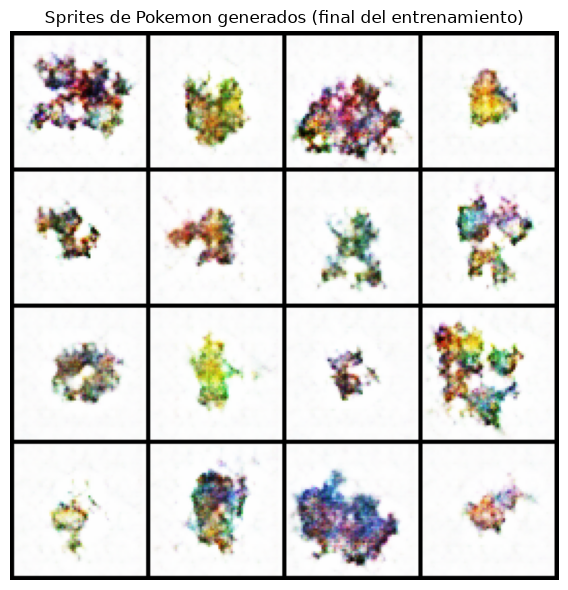

In [ ]:
G.eval()
with torch.no_grad():
    final_fake = G(fixed_noise).detach().cpu()

# Desnormalizar de [-1, 1] (salida de Tanh) a [0, 255]
final_fake_denorm = (final_fake + 1) / 2 * 255
final_fake_denorm = final_fake_denorm.clamp(0, 255).to(torch.uint8)

# make_grid espera floats; reescalamos a [0,1] solo para el despliegue
grid_final = vutils.make_grid(final_fake_denorm.float() / 255.0, nrow=4, padding=2)

plt.figure(figsize=(6, 6))
plt.axis("off")
plt.title("Sprites de Pokemon generados (final del entrenamiento)")
plt.imshow(np.transpose(grid_final.numpy(), (1, 2, 0)))
plt.tight_layout()
plt.show()

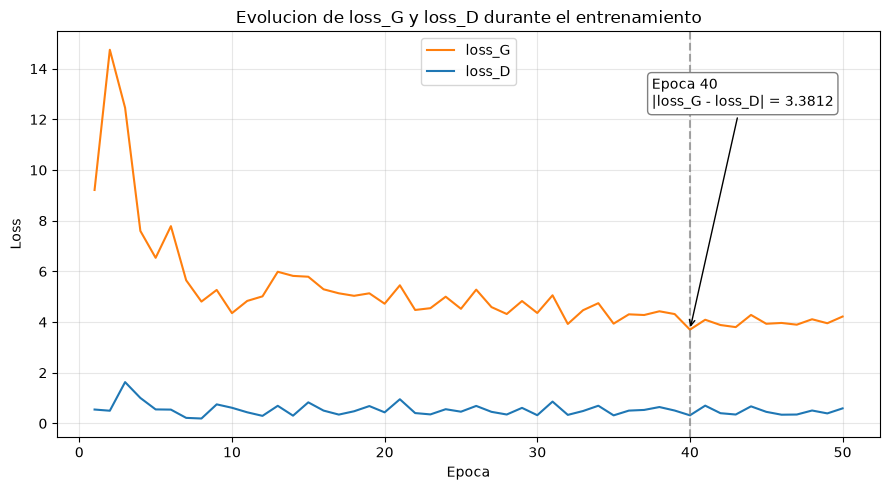

Punto de mayor cercania entre las perdidas: epoca 40 (loss_G=3.6999, loss_D=0.3186)


In [ ]:
losses_G_arr = np.array(losses_G)
losses_D_arr = np.array(losses_D)
diff = np.abs(losses_G_arr - losses_D_arr)
closest_epoch = int(np.argmin(diff))  # indice 0-based

plt.figure(figsize=(9, 5))
plt.plot(range(1, NUM_EPOCHS + 1), losses_G_arr, label="loss_G", color="tab:orange")
plt.plot(range(1, NUM_EPOCHS + 1), losses_D_arr, label="loss_D", color="tab:blue")
plt.axvline(closest_epoch + 1, color="gray", linestyle="--", alpha=0.7)

y_max = max(losses_G_arr.max(), losses_D_arr.max())
plt.annotate(
    f"Epoca {closest_epoch + 1}\n|loss_G - loss_D| = {diff[closest_epoch]:.4f}",
    xy=(closest_epoch + 1, losses_G_arr[closest_epoch]),
    xytext=(min(closest_epoch + 1 + NUM_EPOCHS * 0.08, NUM_EPOCHS * 0.75), y_max * 0.85),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10,
    bbox=dict(boxstyle="round", fc="white", ec="gray"),
)

plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.title("Evolucion de loss_G y loss_D durante el entrenamiento")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Punto de mayor cercania entre las perdidas: epoca {closest_epoch + 1} "
      f"(loss_G={losses_G_arr[closest_epoch]:.4f}, loss_D={losses_D_arr[closest_epoch]:.4f})")

# Task 2 - Dinámica adversarial y divergencia de Jensen-Shannon

<!-- madagascar -->

Los experimentos de esta sección usan instancias independientes de `Generator` y `Discriminator`; por lo tanto, no modifican los modelos `G` y `D` ni los historiales de Task 1.

## Task 2.1 - Cinco actualizaciones de D por cada actualización de G

Se entrenará durante 20 épocas con una razón exacta $n_D:n_G=5:1$. Se registran las pérdidas medias por época y la norma $\ell_2$ global del gradiente del generador.

In [ ]:
NUM_EPOCHS_COLLAPSE = 20
D_STEPS_PER_G = 5

# Instancias nuevas: el experimento no sobrescribe G, D, opt_G ni opt_D de Task 1.
torch.manual_seed(SEED + 1)
G_collapse = Generator().to(device)
D_collapse = Discriminator().to(device)
G_collapse.apply(weights_init)
D_collapse.apply(weights_init)

criterion_collapse = nn.BCELoss()
opt_G_collapse = optim.Adam(G_collapse.parameters(), lr=LR, betas=BETAS)
opt_D_collapse = optim.Adam(D_collapse.parameters(), lr=LR, betas=BETAS)
fixed_noise_collapse = torch.randn(16, Z_DIM, 1, 1, device=device)
losses_D_collapse, losses_G_collapse = [], []
grad_norms_G_collapse, img_grids_collapse = [], []
updates_D_collapse = updates_G_collapse = 0

In [ ]:
for epoch in range(NUM_EPOCHS_COLLAPSE):
    epoch_loss_D = epoch_loss_G = epoch_grad_norm_G = 0.0
    num_updates_G_epoch = 0
    G_collapse.train()
    D_collapse.train()

    for real_imgs in dataloader:
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)
        labels_real = torch.full((batch_size,), REAL_LABEL, device=device)
        labels_fake = torch.full((batch_size,), FAKE_LABEL, device=device)

        # Cinco pasos completos de D antes de cada paso de G.
        G_collapse.eval()  # evita actualizar el estado de BatchNorm de G
        D_collapse.train()
        for _ in range(D_STEPS_PER_G):
            opt_D_collapse.zero_grad(set_to_none=True)
            loss_D_real = criterion_collapse(D_collapse(real_imgs), labels_real)
            noise_d = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
            with torch.no_grad():
                fake_imgs_d = G_collapse(noise_d)
            loss_D_fake = criterion_collapse(D_collapse(fake_imgs_d), labels_fake)
            loss_D_collapse = loss_D_real + loss_D_fake
            loss_D_collapse.backward()
            opt_D_collapse.step()
            epoch_loss_D += loss_D_collapse.item()
            updates_D_collapse += 1

        # Un paso de G con la pérdida no saturante BCE(target=1).
        G_collapse.train()
        D_collapse.eval()  # evita actualizar el estado de BatchNorm de D
        for parameter in D_collapse.parameters():
            parameter.requires_grad_(False)
        opt_G_collapse.zero_grad(set_to_none=True)
        noise_g = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
        loss_G_collapse = criterion_collapse(D_collapse(G_collapse(noise_g)), labels_real)
        loss_G_collapse.backward()
        grad_norm_G = sum(
            parameter.grad.detach().norm(2).item() ** 2
            for parameter in G_collapse.parameters() if parameter.grad is not None
        ) ** 0.5
        opt_G_collapse.step()
        for parameter in D_collapse.parameters():
            parameter.requires_grad_(True)

        epoch_loss_G += loss_G_collapse.item()
        epoch_grad_norm_G += grad_norm_G
        updates_G_collapse += 1
        num_updates_G_epoch += 1

    avg_loss_D_collapse = epoch_loss_D / (D_STEPS_PER_G * num_updates_G_epoch)
    avg_loss_G_collapse = epoch_loss_G / num_updates_G_epoch
    avg_grad_norm_G_collapse = epoch_grad_norm_G / num_updates_G_epoch
    losses_D_collapse.append(avg_loss_D_collapse)
    losses_G_collapse.append(avg_loss_G_collapse)
    grad_norms_G_collapse.append(avg_grad_norm_G_collapse)

    G_collapse.eval()
    with torch.no_grad():
        fake_fixed_epoch = G_collapse(fixed_noise_collapse).cpu()
        img_grids_collapse.append(
            vutils.make_grid(((fake_fixed_epoch + 1) / 2).clamp(0, 1), nrow=4, padding=2)
        )
    print(f"Epoca [{epoch + 1}/{NUM_EPOCHS_COLLAPSE}]  loss_D: {avg_loss_D_collapse:.4f}  "
          f"loss_G: {avg_loss_G_collapse:.4f}  ||grad G||_2: {avg_grad_norm_G_collapse:.4e}")

assert updates_D_collapse == D_STEPS_PER_G * updates_G_collapse
print(f"Razon verificada: {updates_D_collapse} actualizaciones de D / "
      f"{updates_G_collapse} de G = {D_STEPS_PER_G}:1")

In [ ]:
epochs_collapse = np.arange(1, NUM_EPOCHS_COLLAPSE + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_collapse, losses_D_collapse, label="loss_D")
axes[0].plot(epochs_collapse, losses_G_collapse, label="loss_G")
axes[0].set(title="Perdidas con razon 5:1", xlabel="Epoca", ylabel="BCE media")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_collapse, grad_norms_G_collapse, color="tab:green")
axes[1].set(title="Norma del gradiente de G", xlabel="Epoca",
            ylabel=r"$\|\nabla_{\theta_G} L_G\|_2$")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

G_collapse.eval()
with torch.no_grad():
    generated_fixed = G_collapse(fixed_noise_collapse).cpu()
generated_fixed_01 = ((generated_fixed + 1) / 2).clamp(0, 1)
grid_collapse = vutils.make_grid(generated_fixed_01, nrow=4, padding=2)
flat_generated = generated_fixed_01.flatten(start_dim=1)
diversity_l1_collapse = (torch.pdist(flat_generated, p=1) / flat_generated.shape[1]).mean().item()
pixel_std_collapse = generated_fixed_01.std(dim=0, unbiased=False).mean().item()

# Referencia cuantitativa con el G entrenado en Task 1 y el mismo ruido.
task1_was_training = G.training
G.eval()
with torch.no_grad():
    generated_task1_01 = ((G(fixed_noise_collapse).cpu() + 1) / 2).clamp(0, 1)
if task1_was_training:
    G.train()
flat_task1 = generated_task1_01.flatten(start_dim=1)
diversity_l1_task1 = (torch.pdist(flat_task1, p=1) / flat_task1.shape[1]).mean().item()
diversity_ratio = diversity_l1_collapse / max(diversity_l1_task1, np.finfo(float).eps)

plt.figure(figsize=(6, 6))
plt.axis("off"); plt.title("Ruido fijo: experimento 5D:1G")
plt.imshow(np.transpose(grid_collapse.numpy(), (1, 2, 0)))
plt.tight_layout(); plt.show()
print(f"Diversidad L1 media entre pares (5D:1G): {diversity_l1_collapse:.6f}")
print(f"Diversidad L1 media entre pares (Task 1): {diversity_l1_task1:.6f}")
print(f"Razon de diversidad 5D:1G / Task 1: {diversity_ratio:.6f}")
print(f"Desviacion estandar media por pixel/canal (5D:1G): {pixel_std_collapse:.6f}")

### Respuestas Task 2.1

**a) Por qué cinco actualizaciones de $D$ por cada una de $G$ pueden inducir colapso modal.** Esta asimetría permite que $D$ se aproxime rápidamente a una separación casi perfecta mientras $G$ cambia poco. Sea $D(x)=\sigma(a_D(x))$. Para la pérdida minimax saturante, $L_G^{\mathrm{sat}}=\mathbb{E}_z[\log(1-D(G(z)))]$, se cumple $\partial L_G^{\mathrm{sat}}/\partial a_D=-D(G(z))\to0$ cuando $D(G(z))\approx0$. En ese caso, la señal que llega a $G$ desaparece y este no obtiene una dirección para abandonar el modo en el que quedó concentrado. Sin embargo, el notebook **no usa esa pérdida**: usa la no saturante $L_G^{\mathrm{NS}}=-\mathbb{E}_z[\log D(G(z))]$ mediante BCE con objetivo 1, para la cual $\partial L_G^{\mathrm{NS}}/\partial a_D=D(G(z))-1\to-1$. Por tanto, $D(G(z))\approx0$ por sí solo **no demuestra** que $\nabla_{\theta_G}L_G$ sea nulo bajo la pérdida implementada.

Aun con la pérdida no saturante, $\nabla_{\theta_G}L_G=\mathbb{E}_z[J_G(z)^\top J_{a_D}(G(z))^\top(D(G(z))-1)]$ puede ser pequeño si un discriminador sobreentrenado desarrolla regiones localmente planas o saturadas respecto de su entrada, es decir, si $J_{a_D}(G(z))$ es pequeño. Además, cuando muchas entradas $z$ ya producen muestras casi iguales, reciben gradientes similares y se desplazan hacia el mismo modo; como no hay muestras en los modos ausentes, esos gradientes no aportan una dirección para recuperarlos. Así, $G$ puede quedar atrapado sin una señal útil de recuperación, aunque el factor de salida no saturante no desaparezca. La norma almacenada en `grad_norms_G_collapse` es la que debe comprobar experimentalmente si el gradiente realmente se deteriora; no corresponde inferirlo únicamente de $D(G(z))\approx0$.

**b) Valor de $D^*(x)$ sobre una imagen repetida.** El discriminador óptimo para un generador fijo es $D^*(x)=p_{\mathrm{data}}(x)/(p_{\mathrm{data}}(x)+p_G(x))$. En un sprite que $G$ repite, $p_G$ concentra mucha masa y normalmente domina a $p_{\mathrm{data}}$, por lo que $D^*(x)\approx0$. Si ese sprite no pertenece al soporte de los datos y $p_{\mathrm{data}}(x)=0$, entonces $D^*(x)=0$ exactamente. El valor $1/2$ solo corresponde al equilibrio local $p_G(x)=p_{\mathrm{data}}(x)$, no al colapso modal descrito.

**c) Modificación concreta del loop: instance noise con decaimiento.** Se puede añadir ruido gaussiano de igual distribución a imágenes reales y falsas justo antes de cada evaluación de $D$, incluida la evaluación usada para actualizar $G$, con una desviación $\sigma$ que disminuya por época:

```python
sigma = sigma_0 * max(0.0, 1.0 - epoch / decay_epochs)
real_in = real_imgs + sigma * torch.randn_like(real_imgs)
fake_in = fake_imgs + sigma * torch.randn_like(fake_imgs)
loss_D = BCE(D(real_in), real_targets) + BCE(D(fake_in.detach()), fake_targets)
loss_G = BCE(D(fake_in), real_targets)
```

El ruido convoluciona y suaviza los soportes efectivos de $p_{\mathrm{data}}$ y $p_G$, crea solapamiento cuando al inicio serían fácilmente separables y dificulta que $D$ alcance una frontera perfecta demasiado pronto. Esto favorece que $J_{a_D}(G(z))$ conserve gradientes respecto de la entrada más informativos para actualizar $G$; el decaimiento retira gradualmente la regularización a medida que mejora el generador. Es una mitigación implementable, no una garantía de que el colapso modal no ocurra.

**Interpretación adicional de la grilla y las métricas.** La grilla mantiene fijas 16 entradas latentes. `diversity_l1_collapse` y `pixel_std_collapse` cuantifican variación entre sus salidas, mientras que `diversity_ratio` compara esa diversidad con Task 1 usando el mismo ruido. Valores bajos o imágenes visualmente repetidas son consistentes con colapso, pero estas métricas no prueban por sí solas la cobertura de todos los modos reales y deben interpretarse con los resultados efectivamente registrados.

## Task 2.2 - Estimación de la divergencia de Jensen-Shannon

En Task 1, `loss_D` es la suma de las BCE para datos reales y falsos. Por tanto,

$$V(D,G)=\mathbb{E}_{x\sim p_{\mathrm{data}}}\log D(x)+\mathbb{E}_{z}\log(1-D(G(z)))=-\,loss_D.$$

Si $D=D^*$ es óptimo para un $G$ fijo, $V(D^*,G)=-\log 4+2\,\operatorname{JSD}(p_{\mathrm{data}}\|p_G)$ y $\widehat{\operatorname{JSD}}=(-loss_D+\log4)/2$. `loss_G` no se suma: en Task 1 es la pérdida no saturante $-\mathbb{E}_z\log D(G(z))$, una función alternativa para actualizar $G$, y no pertenece a la identidad de $V(D,G)$.

In [ ]:
losses_D_task1 = np.asarray(losses_D, dtype=float)
losses_G_task1 = np.asarray(losses_G, dtype=float)
if losses_D_task1.size == 0:
    raise RuntimeError("Ejecute primero el entrenamiento de Task 1 para obtener losses_D.")
if losses_D_task1.shape != losses_G_task1.shape:
    raise ValueError("Los historiales losses_D y losses_G de Task 1 deben tener la misma longitud.")

value_hat_task1 = -losses_D_task1
jsd_hat_raw = (value_hat_task1 + np.log(4.0)) / 2.0
epochs_task1 = np.arange(1, losses_D_task1.size + 1)
plt.figure(figsize=(9, 5))
plt.plot(epochs_task1, jsd_hat_raw, label=r"$\widehat{JSD}$ cruda", color="tab:purple")
plt.axhline(0, color="black", linestyle="--", linewidth=1.2, label="Limite teorico: 0")
plt.xlabel("Epoca"); plt.ylabel(r"$(-loss_D + \log 4)/2$")
plt.title("Estimacion de JSD a partir de loss_D de Task 1")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

negative_count = int(np.count_nonzero(jsd_hat_raw < 0))
print(f"Epocas con estimacion cruda negativa: {negative_count}/{jsd_hat_raw.size}")
print(f"Estimacion cruda inicial: {jsd_hat_raw[0]:.6f}")
print(f"Estimacion cruda final: {jsd_hat_raw[-1]:.6f}")
print("losses_G se valida como historial paralelo, pero no interviene en la identidad de V(D,G).")

### Respuestas Task 2.2

**a) Sesgo por un discriminador subóptimo.** Para un generador fijo, $D^*$ maximiza la función de valor, de modo que $V(D,G)\leq V(D^*,G)$. Al aplicar la transformación afín, $\widehat{\operatorname{JSD}}(D,G)\leq\operatorname{JSD}(p_{\mathrm{data}}\|p_G)$. Por ello, el discriminador entrenado pero no óptimo **subestima** la JSD teórica. Pueden aparecer estimaciones crudas negativas porque $V(D,G)$ puede ser menor que $-\log4$; se muestran sin recorte y no constituyen una JSD válida.

**b) Convergencia.** En el equilibrio ideal $p_G=p_{\mathrm{data}}$, se cumple $D^*(x)=1/2$, $V(D^*,G)=-\log4$ y $\operatorname{JSD}=0$. La línea horizontal marca ese límite. **La comparación experimental debe completarse con la curva y los valores inicial/final impresos; no se afirma convergencia sin esos outputs.** Oscilaciones, valores negativos o falta de acercamiento sostenido a cero pueden reflejar la dinámica no equilibrada y la no optimalidad de $D$, no una divergencia negativa real.